In [1]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import bar_label
from plotly.graph_objs.layout import legend
from statsmodels.miscmodels import count

In [2]:
df = pd.read_csv("QS_World_University_Rankings_2025_Top_global_universities (1).csv", encoding="utf-8", encoding_errors="ignore")
df.head()

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7


In [3]:
df.columns

Index(['RANK_2025', 'RANK_2024', 'Institution_Name', 'Location', 'Region',
       'SIZE', 'FOCUS', 'RES.', 'STATUS', 'Academic_Reputation_Score',
       'Academic_Reputation_Rank', 'Employer_Reputation_Score',
       'Employer_Reputation_Rank', 'Faculty_Student_Score',
       'Faculty_Student_Rank', 'Citations_per_Faculty_Score',
       'Citations_per_Faculty_Rank', 'International_Faculty_Score',
       'International_Faculty_Rank', 'International_Students_Score',
       'International_Students_Rank', 'International_Research_Network_Score',
       'International_Research_Network_Rank', 'Employment_Outcomes_Score',
       'Employment_Outcomes_Rank', 'Sustainability_Score',
       'Sustainability_Rank', 'Overall_Score'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   object 
 1   RANK_2024                             1482 non-null   object 
 2   Institution_Name                      1503 non-null   object 
 3   Location                              1503 non-null   object 
 4   Region                                1503 non-null   object 
 5   SIZE                                  1503 non-null   object 
 6   FOCUS                                 1503 non-null   object 
 7   RES.                                  1503 non-null   object 
 8   STATUS                                1466 non-null   object 
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank              1503 non-null   object 
 11  Employer_Reputati

In [5]:
df.describe()

,Academic_Reputation_Score,Employer_Reputation_Score,Faculty_Student_Score,Citations_per_Faculty_Score,International_Faculty_Score,International_Students_Score,International_Research_Network_Score,Employment_Outcomes_Score,Sustainability_Score
count,1503.000000,1503.000000,1503.000000,1503.000000,1403.000000,1445.000000,1502.000000,1503.000000,1484.000000
mean,20.286693,19.787292,28.128676,23.503460,30.736707,25.580346,50.129095,23.825083,24.309299
std,22.326168,23.784738,27.613017,27.870692,34.344365,31.098689,29.866588,27.351315,31.074718
min,1.300000,1.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.200000,1.000000
25%,6.300000,4.300000,7.300000,2.800000,4.200000,2.900000,22.725000,4.000000,1.300000
50%,11.000000,9.400000,16.000000,9.900000,12.500000,9.600000,51.100000,11.800000,6.750000
75%,23.500000,25.300000,40.400000,36.400000,51.600000,38.300000,77.100000,33.400000,39.500000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [6]:
df["STATUS"].unique()

array(['B', 'A', 'C', nan], dtype=object)

In [7]:
df.nunique()

RANK_2025                                388
RANK_2024                                378
Institution_Name                        1503
Location                                 106
Region                                     6
SIZE                                       4
FOCUS                                      4
RES.                                       4
STATUS                                     3
Academic_Reputation_Score                472
Academic_Reputation_Rank                 601
Employer_Reputation_Score                500
Employer_Reputation_Rank                 601
Faculty_Student_Score                    590
Faculty_Student_Rank                     683
Citations_per_Faculty_Score              566
Citations_per_Faculty_Rank               699
International_Faculty_Score              531
International_Faculty_Rank               680
International_Students_Score             521
International_Students_Rank              690
International_Research_Network_Score     764
Internatio

In [8]:
df.nunique() < 2

RANK_2025                               False
RANK_2024                               False
Institution_Name                        False
Location                                False
Region                                  False
SIZE                                    False
FOCUS                                   False
RES.                                    False
STATUS                                  False
Academic_Reputation_Score               False
Academic_Reputation_Rank                False
Employer_Reputation_Score               False
Employer_Reputation_Rank                False
Faculty_Student_Score                   False
Faculty_Student_Rank                    False
Citations_per_Faculty_Score             False
Citations_per_Faculty_Rank              False
International_Faculty_Score             False
International_Faculty_Rank              False
International_Students_Score            False
International_Students_Rank             False
International_Research_Network_Sco

In [9]:
df.select_dtypes(include='number').count(axis=1)

0       9
1       9
2       9
3       9
4       9
       ..
1498    9
1499    9
1500    9
1501    9
1502    9
Length: 1503, dtype: int64

In [10]:
df["RANK_2024"] = df["RANK_2024"].fillna(df["RANK_2025"])

In [11]:
df[df["RANK_2024"].isnull()]

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score


In [12]:
df["Null_Values"] = df.isnull().sum(axis=1)

In [13]:
df["Null_Values"].unique()

array([0, 1, 2, 5, 4, 3, 6, 7], dtype=int64)

In [14]:
df[df["Null_Values"] > 6]

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score,Null_Values
865,851-900,851-900,Kyrgyz Russian Slavic University,Kyrgyzstan,Asia,M,CO,MD,A,9.3,...,NaN,NaN,3.1,701+,24.1,470,NaN,NaN,NaN,7


In [15]:
def convert_rank(x):
    x = str(x).strip()
    if "-" in x:
        low, high = map(int, x.split("-"))
        return (low + high) // 2
    elif "+" in x:
        return int(x.replace("+", ""))
    else:
        return int(x)

df["RANK_2024"] = df["RANK_2024"].apply(convert_rank)
df["RANK_2025"] = df["RANK_2025"].apply(convert_rank)

In [16]:
df['RANK_2024'].unique()

array([   1,    6,    3,    4,    2,    5,    7,    8,    9,   15,   12,
         10,   14,   17,   26,   13,   19,   25,   11,   16,   24,   21,
         36,   22,   37,   30,   34,   41,   28,   23,   32,   47,   42,
         50,   40,   43,   29,   38,   33,   51,   60,   44,   46,   45,
         56,   55,   53,   76,   65,   52,   54,   57,   70,   61,   59,
         68,   58,   79,   69,   67,   64,   95,   62,   71,   73,   85,
         63,   72,   84,   81,   89,   75,   87,   91,   80,   90,   78,
         83,   99,  103,   93,  111,   98,  100,  106,  107,  180,  119,
        105,  104,  113,  121,  123,  109,   97,  112,  102,  115,  149,
        117,  145,  114,  173,  140,  116,  120,  171,  118,  110,  124,
        134,  154,  130,  137,  159,  129,  122,  126,  143,  141,  158,
        197,  148,  136,  176,  128,  132,  151,  139,  164,  230,  162,
        153,  169,  196,  183,  189,  163,  198,  188,  199,  310,  167,
        184,  214,  203,  205,  216,  209,  187,  1

In [17]:
df2 = df[df['Null_Values'] > 3].copy()

In [18]:
df2

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score,Null_Values
439,440,429,Singapore University of Technology and Design,Singapore,Asia,S,SP,VH,NaN,7.4,...,NaN,NaN,31.2,701+,4.6,701+,1.1,701+,27,5
564,565,600,Nanjing University of Science and Technology,China (Mainland),Asia,L,FO,VH,A,5.7,...,NaN,NaN,38.7,701+,3.7,701+,2.3,701+,22,4
681,685,785,China University of Mining and Technology,China (Mainland),Asia,L,CO,VH,A,3.5,...,NaN,NaN,52.4,701+,10.1,701+,2.8,701+,NaN,5
691,695,1300,Norwegian University of Life Sciences (UMB),Norway,Europe,M,FO,VH,NaN,5.8,...,NaN,NaN,74.7,414,18.6,592,9.9,667=,NaN,6
721,715,1300,Universit de Franche-Comt,France,Europe,S,CO,VH,A,6.5,...,NaN,NaN,76.7,384,3.2,701+,1.7,701+,NaN,5
742,745,582,Universidad Catlica Andres Bello,Venezuela,Americas,M,FO,MD,B,28.4,...,2.7,701+,NaN,NaN,18.9,583,NaN,NaN,NaN,5
770,775,875,Addis Ababa University,Ethiopia,Africa,XL,CO,HI,NaN,6.4,...,NaN,NaN,55.2,694,95.5,49,3.3,701+,NaN,6
848,825,1401,University of Stavanger,Norway,Europe,M,CO,VH,NaN,7.1,...,NaN,NaN,69.6,489,10.0,701+,5.1,701+,NaN,6
865,875,875,Kyrgyz Russian Slavic University,Kyrgyzstan,Asia,M,CO,MD,A,9.3,...,NaN,NaN,3.1,701+,24.1,470,NaN,NaN,NaN,7
907,925,1401,Georgian Technical University,Georgia,Asia,L,FO,MD,A,7.1,...,NaN,NaN,5.4,701+,25.9,457,1.0,701+,NaN,5


In [19]:
df = df[df["Null_Values"] <= 3]

In [20]:
df.drop(columns=["Null_Values"], inplace=True)
df2.drop(columns=["Null_Values"], inplace=True)

In [21]:
df

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1498,1401,1300,University of Montana Missoula,United States,Americas,M,CO,HI,A,3.0,...,701+,1.9,701+,6.5,701+,3.1,701+,1.0,701+,NaN
1499,1401,1401,University of Oradea,Romania,Europe,L,FC,MD,A,5.6,...,701+,5.2,701+,34.5,701+,6.2,701+,2.3,701+,NaN
1500,1401,1300,University of San Carlos,Philippines,Asia,M,CO,MD,C,7.2,...,701+,2.1,701+,6.4,701+,9.6,701+,1.0,701+,NaN
1501,1401,1401,"University Politehnica of Timisoara, UPT",Romania,Europe,L,FO,VH,A,4.1,...,701+,2.5,701+,18.6,701+,3.9,701+,1.1,701+,NaN


In [22]:
df.isnull().sum()

RANK_2025                                 0
RANK_2024                                 0
Institution_Name                          0
Location                                  0
Region                                    0
SIZE                                      0
FOCUS                                     0
RES.                                      0
STATUS                                   19
Academic_Reputation_Score                 0
Academic_Reputation_Rank                  0
Employer_Reputation_Score                 0
Employer_Reputation_Rank                  0
Faculty_Student_Score                     0
Faculty_Student_Rank                      0
Citations_per_Faculty_Score               0
Citations_per_Faculty_Rank                0
International_Faculty_Score              45
International_Faculty_Rank               45
International_Students_Score              3
International_Students_Rank               3
International_Research_Network_Score      0
International_Research_Network_R

In [23]:
df["International_Faculty_Score"] = (
    df["International_Faculty_Score"]
    .fillna(
        df.groupby("Location")["International_Faculty_Score"]
        .transform("mean")
    )
    .fillna(df["International_Faculty_Score"].mean())
)

In [24]:
df["International_Students_Score"] = (
    df["International_Students_Score"]
    .fillna(
        df.groupby("Location")["International_Students_Score"]
        .transform("mean")
    )
    .fillna(df["International_Students_Score"].mean())
)

In [25]:
df.isnull().sum()

RANK_2025                                 0
RANK_2024                                 0
Institution_Name                          0
Location                                  0
Region                                    0
SIZE                                      0
FOCUS                                     0
RES.                                      0
STATUS                                   19
Academic_Reputation_Score                 0
Academic_Reputation_Rank                  0
Employer_Reputation_Score                 0
Employer_Reputation_Rank                  0
Faculty_Student_Score                     0
Faculty_Student_Rank                      0
Citations_per_Faculty_Score               0
Citations_per_Faculty_Rank                0
International_Faculty_Score               0
International_Faculty_Rank               45
International_Students_Score              0
International_Students_Rank               3
International_Research_Network_Score      0
International_Research_Network_R

In [26]:
df["Sustainability_Score"] = (
    df["Sustainability_Score"]
    .fillna(
        df.groupby("Location")["Sustainability_Score"]
        .transform("mean")
    )
    .fillna(df["Sustainability_Score"].mean())
)

In [27]:
df["STATUS"].fillna("B", inplace=True)

In [28]:
df["STATUS"].unique()

array(['B', 'A', 'C'], dtype=object)

In [29]:
df["International_Faculty_Rank"].unique()

array(['100', '66', '120', '269', '73', '284', '25', '41', '106', '65',
       '188', '182', '148', '365', '42', '347', '33', '87', '57', '623',
       '244', '701+', '181', '315', '132', '28', '111', '236', '225',
       '52', '307', '413', '169', '58', '59', '142', '201', '103', '54',
       '407', '492', '299', '558', '104', '22', '149', '69', '653', '393',
       '40', '587', '206', '139', '590', '39', '472', '262', '324', '647',
       '13', '163', '471', '76', '665', '644', '119', '686', '305', '342',
       '448', '175', '124', '37', '141', '239', '171', '173', '78', '230',
       '346', '556', '549', '101', '133', '125', '533', '242', '524',
       '604', '116', '314', '511', '373', '221', '26', '282', '99', '113',
       '228', '337', '682', '194', '55', '71', '292', '468', '146', '584',
       '257', '454', '272', '180', '96', '94', '24', '45', '632', '523',
       '288', '105', '235', '193', '275', '44', '672', '88', '75', '70',
       '392', '56', '166', '220', '247', '192'

In [30]:
df["International_Students_Rank"].unique()

array(['143', '44', '73', '215', '98', '244', '63', '129', '21', '172',
       '226', '242', '39', '497', '160', '237', '52', '17', '48', '654',
       '140', '264', '238', '230', '90', '14', '41', '64', '124', '89',
       '586', '92', '432', '79', '55', '137', '24', '200', '390', '47',
       '23', '515', '68', '359', '553', '71', '94', '608', '117', '566',
       '283', '12', '701+', '121', '138', '287', '110', '58', '374',
       '234', '243', '7', '305', '315', '156', '685', '321', '451', '57',
       '266', '232', '328', '253', '227', '198', '407', '40', '49', '289',
       '127', '70', '53', '132', '275', '424', '675', '133', '145', '153',
       '446', '325', '114', '207', '330', '149', '613', '307', '337',
       '170', '29', '80', '559', '689', '208', '135', '338', '262', '130',
       '354', '224', '206', '498', '416', '54', '299', '83', '116', '341',
       '192', '391', '188', '122', '217', '286', '147', '672', '112',
       '164', '109', '175', '240', '105', '284', '99', 

In [31]:
df["Sustainability_Rank"].unique()

array(['15=', '6', '126', '130', '127=', '148=', '18', '26=', '190=',
       '253', '71', '2', '9', '330=', '50=', '208=', '101=', '7', '11=',
       '363=', '312', '76=', '197', '1', '114=', '70', '13', '30=', '46=',
       '258=', '22', '211=', '3', '23', '4', '142', '44=', '36', '232=',
       '55=', '254=', '154', '289=', '170=', '440=', '14', '124=', '285=',
       '85', '268', '17', '384=', '103=', '173=', '492=', '132=', '186=',
       '201', '313=', '111', '5', '305=', '94=', '98', '241=', '310=',
       '348=', '202=', '58', '8', '235', '315=', '20', '333', '35', '34',
       '49', '228=', '276=', '43', '19', '37=', '93', '67', '159=',
       '701+', '136=', '28', '435=', '393=', '198=', '530=', '184=',
       '86=', '24=', '164=', '33', '328', '273=', '236=', '59', '371=',
       '68=', '269=', '60', '302=', '54', '10', '196', '62=', '161=',
       '535=', '178=', '343=', '205=', '108', '57', '622', '445=', '265',
       '243=', '113', '245=', '488=', '529', '176=', '567=', '

In [32]:
col = df["International_Faculty_Rank"].astype(str)
invalid = df[
    ~col.str.match(r"^\d+$", na=False)
]["International_Faculty_Rank"].unique()

invalid

array(['701+', '613=', nan, '1='], dtype=object)

In [33]:
col = df["International_Students_Rank"].astype(str)
invalid = df[
    ~col.str.match(r"^\d+$", na=False)
]["International_Students_Rank"].unique()

invalid

array(['701+', nan], dtype=object)

In [34]:
col = df["Sustainability_Rank"].astype(str)
invalid = df[
    ~col.str.match(r"^\d+$", na=False)
]["Sustainability_Rank"].unique()

invalid

array(['15=', '127=', '148=', '26=', '190=', '330=', '50=', '208=',
       '101=', '11=', '363=', '76=', '114=', '30=', '46=', '258=', '211=',
       '44=', '232=', '55=', '254=', '289=', '170=', '440=', '124=',
       '285=', '384=', '103=', '173=', '492=', '132=', '186=', '313=',
       '305=', '94=', '241=', '310=', '348=', '202=', '315=', '228=',
       '276=', '37=', '159=', '701+', '136=', '435=', '393=', '198=',
       '530=', '184=', '86=', '24=', '164=', '273=', '236=', '371=',
       '68=', '269=', '302=', '62=', '161=', '535=', '178=', '343=',
       '205=', '445=', '243=', '245=', '488=', '176=', '567=', '214=',
       '400=', '295=', '424=', '41=', '355=', '81=', '121=', '89=', '78=',
       '456=', '282=', '291=', '271=', '636=', '64=', '513=', '391=',
       '156=', '420=', '471=', '650=', '334=', '428=', '500=', '266=',
       '166=', '379=', '298=', '193=', '181=', '247=', '473=', '152=',
       '597=', '388=', '483=', '217=', '516=', '462=', '563=', '549=',
       '53

In [35]:
def clean_rank(x):
    if pd.isna(x):
        return np.nan

    x = str(x)

    if x[-1] in ["+", "="]:
        x = x[:-1]

    return int(float(x))

df["International_Faculty_Rank"] = (
    df["International_Faculty_Rank"]
    .apply(clean_rank))

df["International_Students_Rank"] = (
    df["International_Students_Rank"]
    .apply(clean_rank))

df["Sustainability_Rank"] = (
    df["Sustainability_Rank"]
    .apply(clean_rank))

df["Academic_Reputation_Rank"] = (
    df["Academic_Reputation_Rank"]
    .apply(clean_rank))

df["Faculty_Student_Rank"] = (
    df["Faculty_Student_Rank"]
    .apply(clean_rank))

df["Citations_per_Faculty_Rank"] = (
    df["Citations_per_Faculty_Rank"]
    .apply(clean_rank))

df["Employer_Reputation_Rank"] = (
    df["Employer_Reputation_Rank"]
    .apply(clean_rank))

df["International_Research_Network_Rank"] = (
    df["International_Research_Network_Rank"]
    .apply(clean_rank))

df['Employment_Outcomes_Rank'] = (
    df['Employment_Outcomes_Rank']
    .apply(clean_rank))

In [36]:
df["International_Students_Rank"] = (
    df["International_Students_Rank"]
    .fillna(
        df.groupby("Location")["International_Students_Rank"]
        .transform("mean")
    )
    .fillna(df["International_Students_Rank"].mean())
)

In [37]:
df["International_Faculty_Rank"] = (
    df["International_Faculty_Rank"]
    .fillna(
        df.groupby("Location")["International_Faculty_Rank"]
        .transform("mean")
    )
    .fillna(df["International_Faculty_Rank"].mean())
)

In [38]:
df["Sustainability_Rank"] = (
    df["Sustainability_Rank"]
    .fillna(
        df.groupby("Location")["Sustainability_Rank"]
        .transform("mean")
    )
    .fillna(df["Sustainability_Rank"].mean())
)

In [39]:
df["Academic_Reputation_Rank"] = (
    df["Academic_Reputation_Rank"]
    .fillna(
        df.groupby("Location")["Academic_Reputation_Rank"]
        .transform("mean")
    )
    .fillna(df["Academic_Reputation_Rank"].mean())
)

In [40]:
df["Faculty_Student_Rank"] = (
    df["Faculty_Student_Rank"]
    .fillna(
        df.groupby("Location")["Faculty_Student_Rank"]
        .transform("mean")
    )
    .fillna(df["Faculty_Student_Rank"].mean())
)

In [41]:
df["Citations_per_Faculty_Rank"] = (
    df["Citations_per_Faculty_Rank"]
    .fillna(
        df.groupby("Location")["Citations_per_Faculty_Rank"]
        .transform("mean")
    )
    .fillna(df["Citations_per_Faculty_Rank"].mean())
)

In [42]:
df["Employer_Reputation_Rank"] = (
    df["Employer_Reputation_Rank"]
    .fillna(
        df.groupby("Location")["Employer_Reputation_Rank"]
        .transform("mean")
    )
    .fillna(df["Employer_Reputation_Rank"].mean())
)

In [43]:
df["International_Research_Network_Rank"] = (
    df["International_Research_Network_Rank"]
    .fillna(
        df.groupby("Location")["International_Research_Network_Rank"]
        .transform("mean")
    )
    .fillna(df["International_Research_Network_Rank"].mean())
)

In [44]:
df['Employment_Outcomes_Rank'] = (
    df['Employment_Outcomes_Rank']
    .fillna(
        df.groupby("Location")['Employment_Outcomes_Rank']
        .transform("mean")
    )
    .fillna(df['Employment_Outcomes_Rank'].mean())
)

In [45]:
df["Institution_Name"] = df["Institution_Name"].astype("string")
df["Location"] = df["Location"].astype("string")
df["STATUS"] = df["STATUS"].astype("string")
df["Region"] = df["Region"].astype("string")
df["SIZE"] = df["SIZE"].astype("string")
df["FOCUS"] = df["FOCUS"].astype("string")
df["RES."] = df["RES."].astype("string")
df["Academic_Reputation_Rank"] = df["Academic_Reputation_Rank"].astype(int)
df["Faculty_Student_Rank"] = df["Faculty_Student_Rank"].astype(int)
df["Citations_per_Faculty_Rank"] = df["Citations_per_Faculty_Rank"].astype(int)
df["Employer_Reputation_Rank"] = df["Employer_Reputation_Rank"].astype(int)
df["International_Research_Network_Rank"] = df["International_Research_Network_Rank"].astype(int)
df['Employment_Outcomes_Rank'] = df['Employment_Outcomes_Rank'].astype(int)

In [46]:
df.head()

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100.0,86.8,143.0,96.0,58,100.0,8,99.0,15.0,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66.0,99.6,44.0,97.4,34,93.4,61,99.7,6.0,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120.0,97.7,73.0,100.0,1,100.0,3,85.0,126.0,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269.0,69.0,215.0,99.6,5,100.0,1,84.4,130.0,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73.0,94.8,98.0,99.3,10,100.0,5,84.8,127.0,96.7


In [47]:
df.dtypes

RANK_2025                                        int64
RANK_2024                                        int64
Institution_Name                        string[python]
Location                                string[python]
Region                                  string[python]
SIZE                                    string[python]
FOCUS                                   string[python]
RES.                                    string[python]
STATUS                                  string[python]
Academic_Reputation_Score                      float64
Academic_Reputation_Rank                         int32
Employer_Reputation_Score                      float64
Employer_Reputation_Rank                         int32
Faculty_Student_Score                          float64
Faculty_Student_Rank                             int32
Citations_per_Faculty_Score                    float64
Citations_per_Faculty_Rank                       int32
International_Faculty_Score                    float64
Internatio

In [48]:
df['Overall_Score'].unique()

array(['100', '98.5', '96.9', '96.8', '96.7', '96.1', '93.9', '93.7',
       '91.6', '90.9', '90.3', '90.1', '88.9', '88.5', '88.4', '87.9',
       '87.6', '87.3', '87.1', '86.5', '86.2', '85.5', '85.2', '84.7',
       '84.1', '83.5', '83.3', '83.2', '83', '82.4', '82.3', '82.1', '82',
       '81.3', '81.2', '81', '80.3', '80.2', '79.8', '79.6', '79', '77.8',
       '77.5', '77.1', '77', '76', '75.7', '75.4', '73.7', '72.9', '72.1',
       '72', '71.6', '71.2', '70.8', '70.7', '70.3', '69.7', '69.5', '69',
       '68.7', '68.2', '67.6', '67.1', '67', '65.7', '65.6', '65.3',
       '65.2', '65', '64.7', '64.1', '63.8', '63.7', '63.5', '62.9',
       '62.4', '61.7', '61.6', '61.5', '61.4', '61.2', '60.6', '60.3',
       '59.9', '59.6', '59.5', '59.4', '59.3', '59.2', '59.1', '58.8',
       '58.5', '58.3', '58.2', '58.6', '57.9', '57.3', '57.2', '57.1',
       '56.8', '56.3', '56.1', '55.8', '55.7', '55.5', '55.2', '55',
       '54.8', '54.5', '54.4', '54.3', '54.2', '54.1', '54', '53.9',

In [49]:
def clean_overall_score(x):
    try:
        return float(x)
    except:
        return np.nan

df["Overall_Score"] = df["Overall_Score"].apply(clean_overall_score)

In [50]:
df["Overall_Score"] = df["Overall_Score"].fillna(
    (
        df["Academic_Reputation_Score"] +
        df["Employer_Reputation_Score"] +
        df["Faculty_Student_Score"] +
        df["Citations_per_Faculty_Score"] +
        df["International_Faculty_Score"] +
        df["International_Students_Score"] +
        df['International_Research_Network_Score'] +
        df["Sustainability_Score"] +
        df["Employment_Outcomes_Score"]
    ) / 9
)

In [51]:
df.dtypes

RANK_2025                                        int64
RANK_2024                                        int64
Institution_Name                        string[python]
Location                                string[python]
Region                                  string[python]
SIZE                                    string[python]
FOCUS                                   string[python]
RES.                                    string[python]
STATUS                                  string[python]
Academic_Reputation_Score                      float64
Academic_Reputation_Rank                         int32
Employer_Reputation_Score                      float64
Employer_Reputation_Rank                         int32
Faculty_Student_Score                          float64
Faculty_Student_Rank                             int32
Citations_per_Faculty_Score                    float64
Citations_per_Faculty_Rank                       int32
International_Faculty_Score                    float64
Internatio

In [52]:
df.isnull().sum() > 0

RANK_2025                               False
RANK_2024                               False
Institution_Name                        False
Location                                False
Region                                  False
SIZE                                    False
FOCUS                                   False
RES.                                    False
STATUS                                  False
Academic_Reputation_Score               False
Academic_Reputation_Rank                False
Employer_Reputation_Score               False
Employer_Reputation_Rank                False
Faculty_Student_Score                   False
Faculty_Student_Rank                    False
Citations_per_Faculty_Score             False
Citations_per_Faculty_Rank              False
International_Faculty_Score             False
International_Faculty_Rank              False
International_Students_Score            False
International_Students_Rank             False
International_Research_Network_Sco

In [53]:
df

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100.0,86.8,143.0,96.0,58,100.0,8,99.0,15.0,100.000000
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66.0,99.6,44.0,97.4,34,93.4,61,99.7,6.0,98.500000
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120.0,97.7,73.0,100.0,1,100.0,3,85.0,126.0,96.900000
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269.0,69.0,215.0,99.6,5,100.0,1,84.4,130.0,96.800000
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73.0,94.8,98.0,99.3,10,100.0,5,84.8,127.0,96.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1498,1401,1300,University of Montana Missoula,United States,Americas,M,CO,HI,A,3.0,...,701.0,1.9,701.0,6.5,701,3.1,701,1.0,701.0,3.966667
1499,1401,1401,University of Oradea,Romania,Europe,L,FC,MD,A,5.6,...,701.0,5.2,701.0,34.5,701,6.2,701,2.3,701.0,7.044444
1500,1401,1300,University of San Carlos,Philippines,Asia,M,CO,MD,C,7.2,...,701.0,2.1,701.0,6.4,701,9.6,701,1.0,701.0,4.766667
1501,1401,1401,"University Politehnica of Timisoara, UPT",Romania,Europe,L,FO,VH,A,4.1,...,701.0,2.5,701.0,18.6,701,3.9,701,1.1,701.0,5.211111


In [54]:
df2

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
439,440,429,Singapore University of Technology and Design,Singapore,Asia,S,SP,VH,NaN,7.4,...,NaN,NaN,NaN,31.2,701+,4.6,701+,1.1,701+,27
564,565,600,Nanjing University of Science and Technology,China (Mainland),Asia,L,FO,VH,A,5.7,...,NaN,NaN,NaN,38.7,701+,3.7,701+,2.3,701+,22
681,685,785,China University of Mining and Technology,China (Mainland),Asia,L,CO,VH,A,3.5,...,NaN,NaN,NaN,52.4,701+,10.1,701+,2.8,701+,NaN
691,695,1300,Norwegian University of Life Sciences (UMB),Norway,Europe,M,FO,VH,NaN,5.8,...,NaN,NaN,NaN,74.7,414,18.6,592,9.9,667=,NaN
721,715,1300,Universit de Franche-Comt,France,Europe,S,CO,VH,A,6.5,...,NaN,NaN,NaN,76.7,384,3.2,701+,1.7,701+,NaN
742,745,582,Universidad Catlica Andres Bello,Venezuela,Americas,M,FO,MD,B,28.4,...,701+,2.7,701+,NaN,NaN,18.9,583,NaN,NaN,NaN
770,775,875,Addis Ababa University,Ethiopia,Africa,XL,CO,HI,NaN,6.4,...,NaN,NaN,NaN,55.2,694,95.5,49,3.3,701+,NaN
848,825,1401,University of Stavanger,Norway,Europe,M,CO,VH,NaN,7.1,...,NaN,NaN,NaN,69.6,489,10.0,701+,5.1,701+,NaN
865,875,875,Kyrgyz Russian Slavic University,Kyrgyzstan,Asia,M,CO,MD,A,9.3,...,NaN,NaN,NaN,3.1,701+,24.1,470,NaN,NaN,NaN
907,925,1401,Georgian Technical University,Georgia,Asia,L,FO,MD,A,7.1,...,NaN,NaN,NaN,5.4,701+,25.9,457,1.0,701+,NaN


In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\Admin\AppData\Local\Temp\ipykernel_24932\114386730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Overall_Score', ylabel='Institution_Name'>

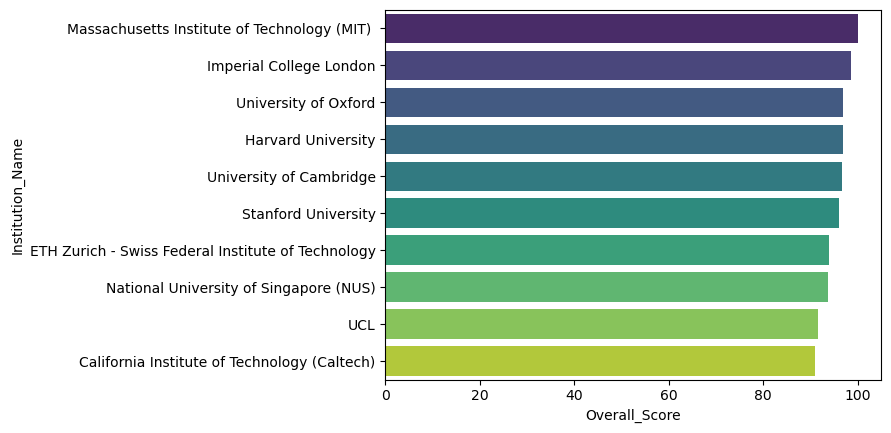

In [56]:
top10 = df.nlargest(10, 'Overall_Score')
sns.barplot(
    data=top10,
    x='Overall_Score',
    y='Institution_Name',
    palette='viridis'
)

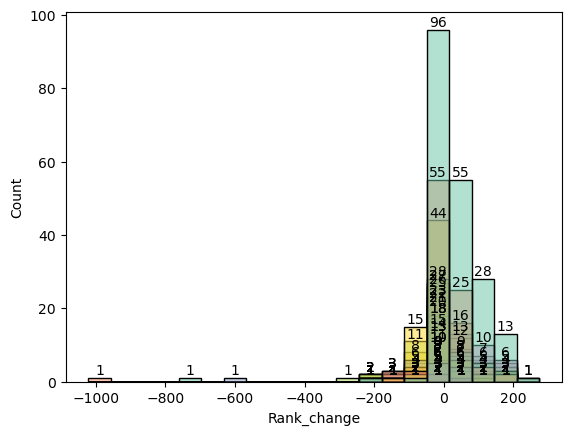

In [57]:
df["Rank_change"] = df["RANK_2025"] - df["RANK_2024"]
ax =   sns.histplot(
        data=df,
        x='Rank_change',
        bins=20,
        hue='Location',
        palette='Set2',
        legend= False
)
for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        if height > 0:
            labels.append(f'{int(height)}')
        else:
            labels.append('')
    ax.bar_label(container, labels=labels)
plt.show()

<Axes: >

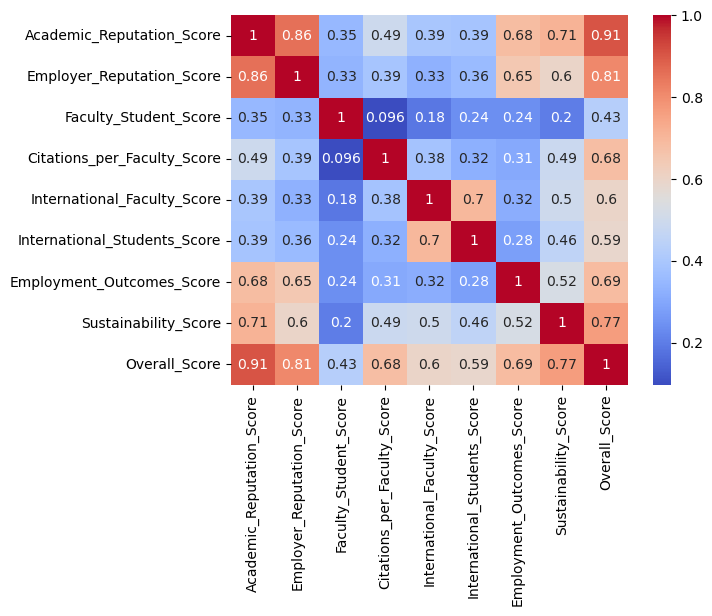

In [58]:
score_cols = [
    'Academic_Reputation_Score',
    'Employer_Reputation_Score',
    'Faculty_Student_Score',
    'Citations_per_Faculty_Score',
    'International_Faculty_Score',
    'International_Students_Score',
    'Employment_Outcomes_Score',
    'Sustainability_Score',
    'Overall_Score'
]

corr = df[score_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

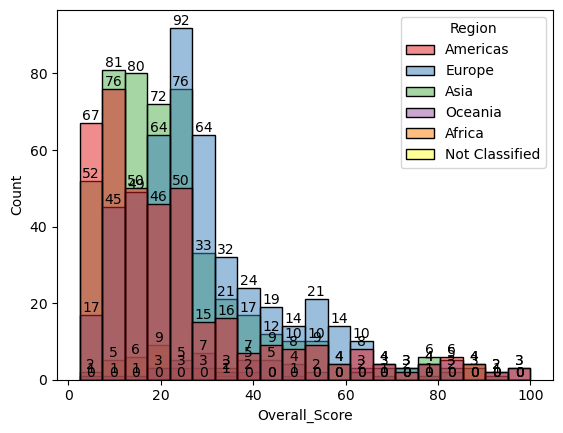

In [70]:
ax = sns.histplot(
        data=df,
        x='Overall_Score',
        bins=20,
        hue='Region',
        palette='Set1',
        legend=True)

for container in ax.containers:
    ax.bar_label(container)
plt.show()

C:\Users\Admin\miniconda3\envs\untitled\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


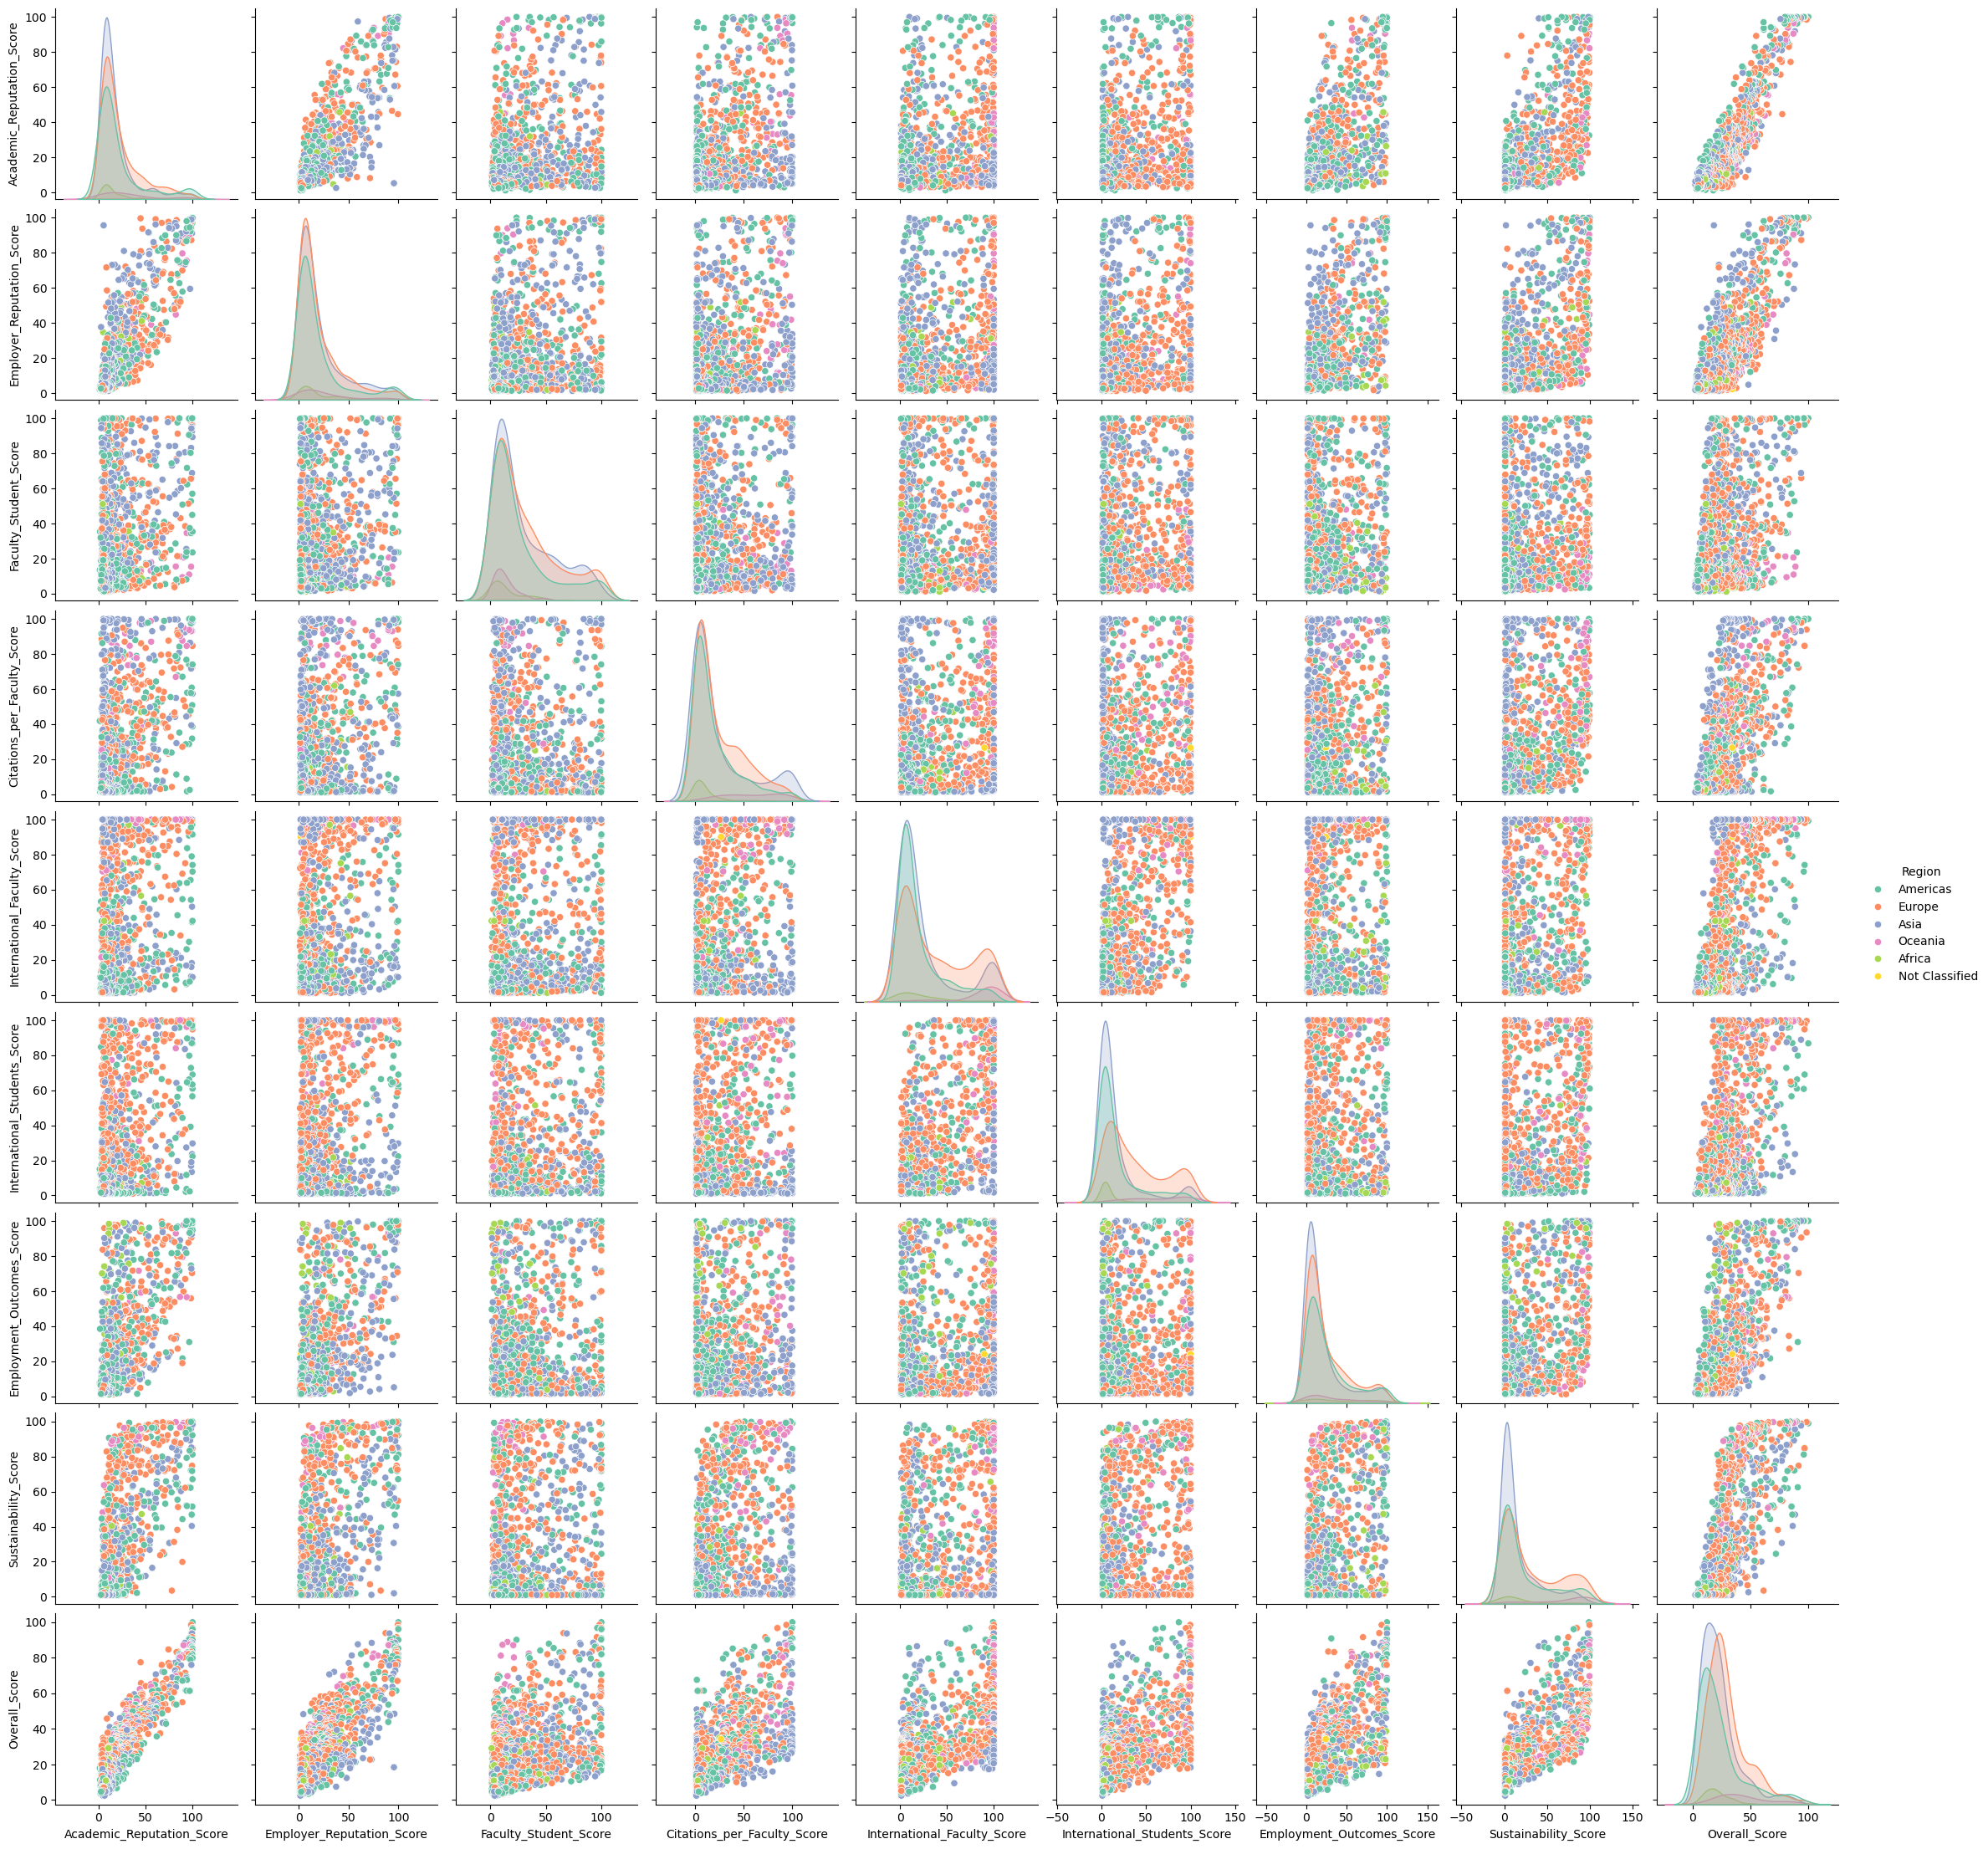

In [71]:
sns.pairplot(
    data=df,
    vars=score_cols,
    hue='Region',
    palette='Set2')

<Axes: xlabel='Academic_Reputation_Score', ylabel='Overall_Score'>

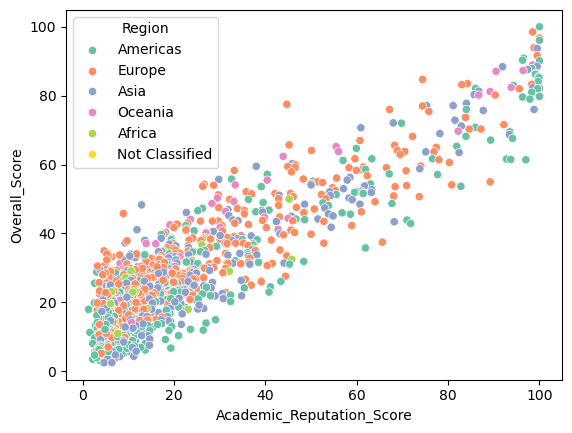

In [72]:
sns.scatterplot(
    data=df,
    x='Academic_Reputation_Score',
    y='Overall_Score',
    hue='Region',
    palette='Set2')

C:\Users\Admin\AppData\Local\Temp\ipykernel_24932\1096649232.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: xlabel='count', ylabel='Region'>

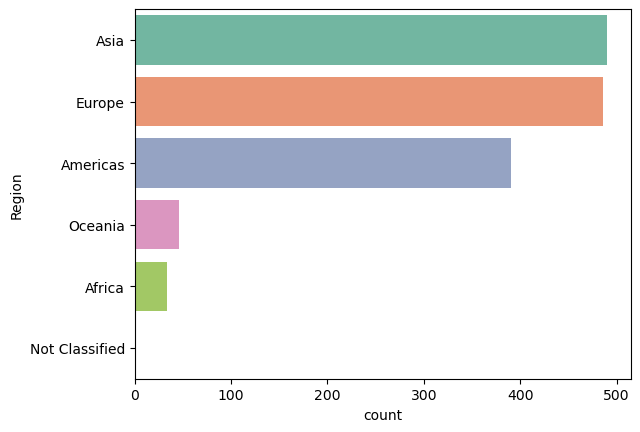

In [74]:
sns.countplot(
    data=df,
    y='Region',
    order=df['Region'].value_counts().index,
    palette='Set2'
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_24932\1613227730.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Overall_Score', ylabel='Region'>

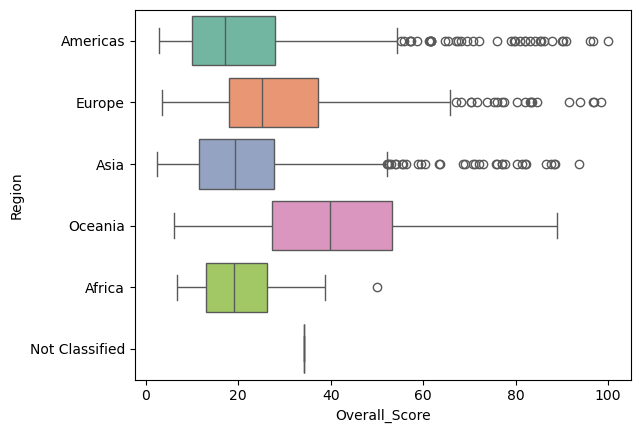

In [75]:
sns.boxplot(
    data=df,
    x='Overall_Score',
    y='Region',
    palette='Set2')

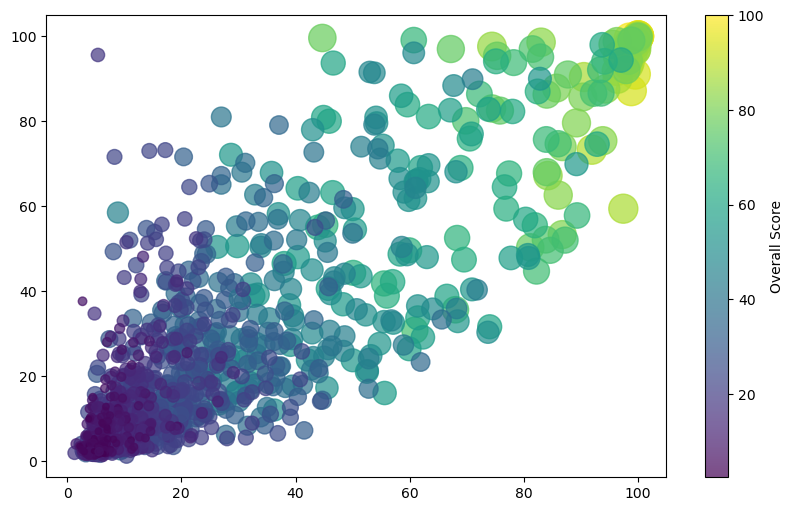

In [76]:
plt.figure(figsize=(10,6))
plt.scatter(
    df['Academic_Reputation_Score'],
    df['Employer_Reputation_Score'],
    s=df['Overall_Score']*5,
    c=df['Overall_Score'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(label='Overall Score')

C:\Users\Admin\AppData\Local\Temp\ipykernel_24932\1847200946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Rank_change', ylabel='Institution_Name'>

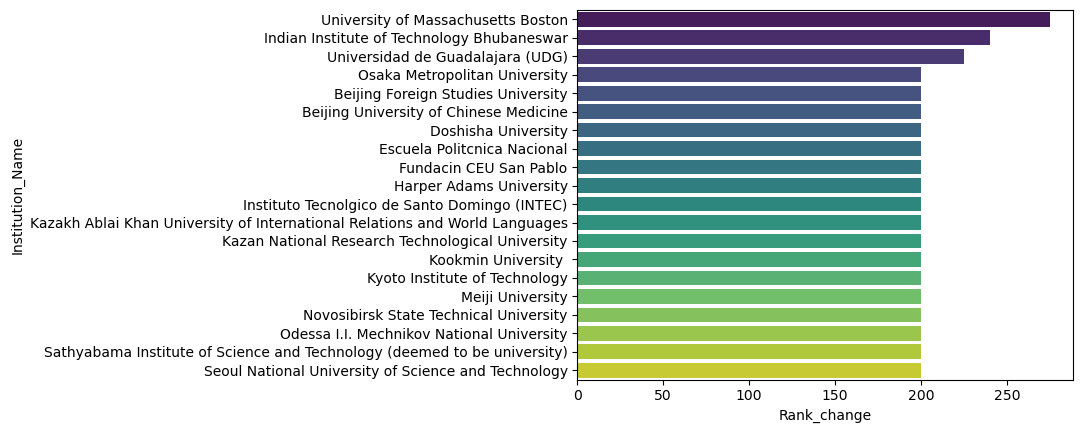

In [82]:
top_improved = df.nlargest(20, 'Rank_change')
sns.barplot(
    data=top_improved,
    x='Rank_change',
    y='Institution_Name',
    palette='viridis'
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_24932\2433480832.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


<Axes: xlabel='Overall_Score', ylabel='Density'>

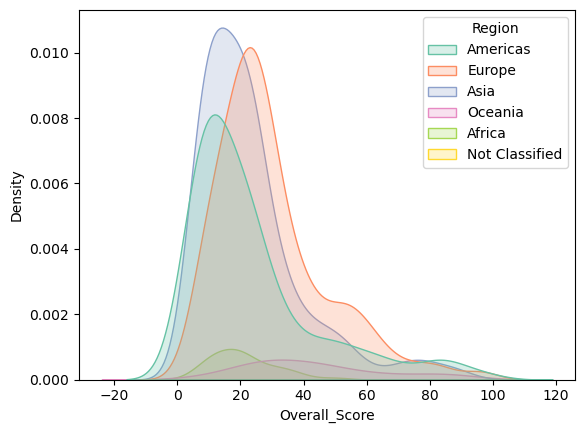

In [83]:
sns.kdeplot(
    data=df,
    x='Overall_Score',
    hue='Region',
    fill=True,
    palette='Set2')

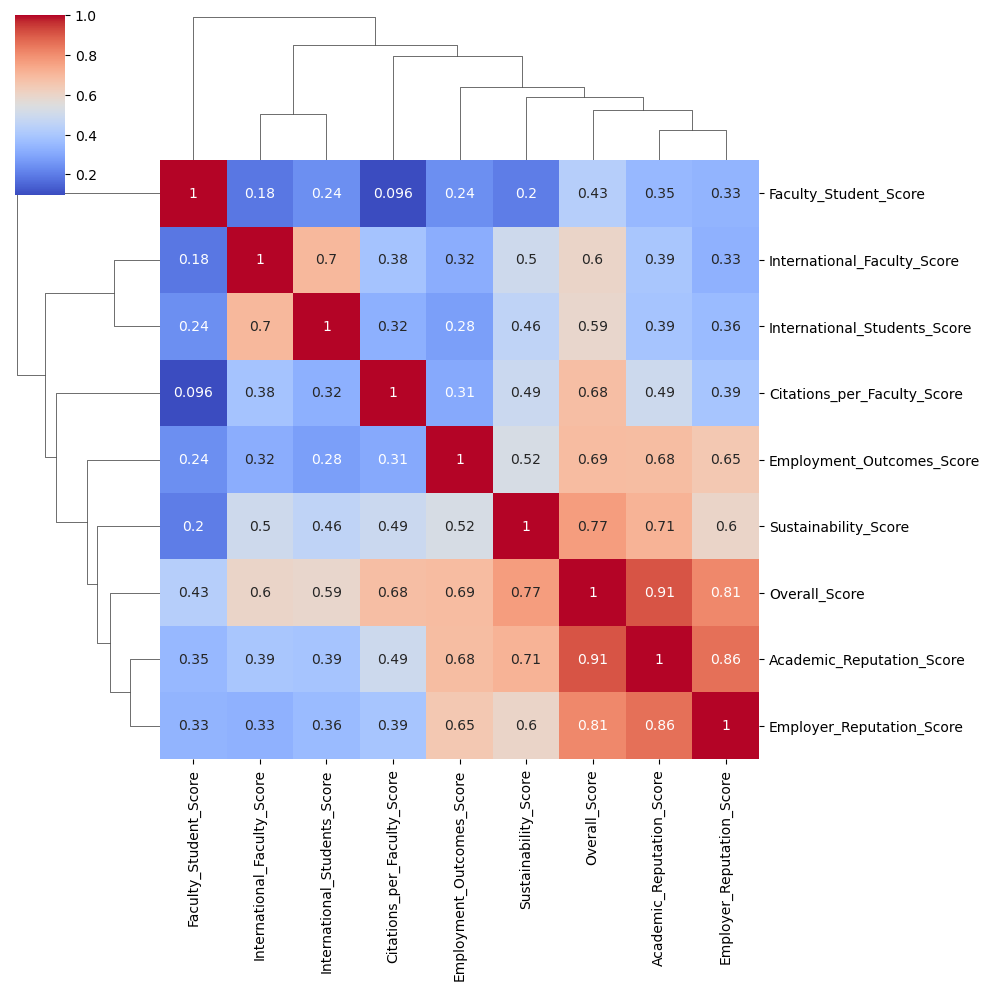

In [84]:
sns.clustermap(
    data=df[score_cols].corr(),
    annot=True,
    cmap='coolwarm',
    figsize=(10, 10))

C:\Users\Admin\miniconda3\envs\untitled\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


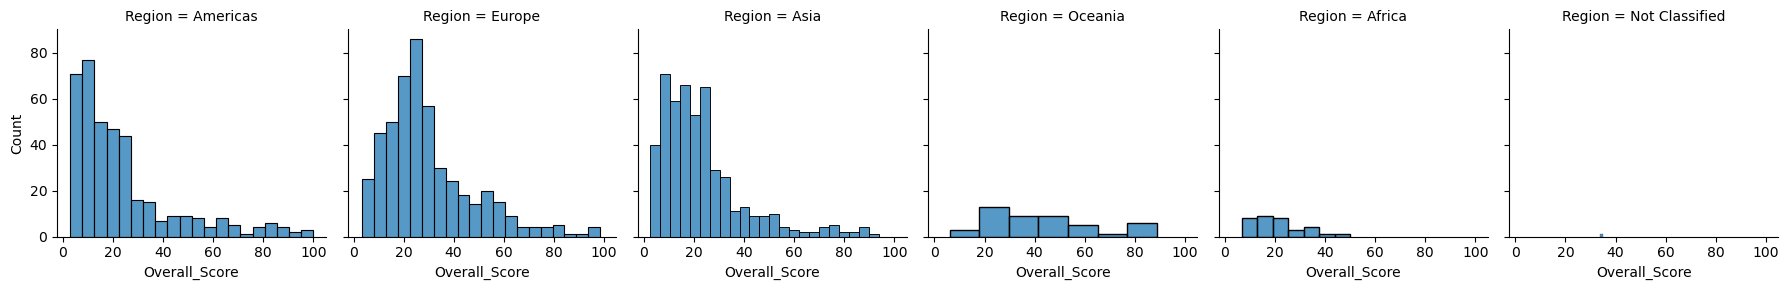

In [86]:
sns.FacetGrid(
    df,
    col='Region'
).map(sns.histplot, 'Overall_Score')